# 🌾 PadiSense — Training YOLOv8 Deteksi Penyakit Daun Padi

**Dataset:** 9 kelas penyakit padi | 6.935 train | 1.730 val

**Model:** YOLOv8n (ringan, cocok untuk demo & Streamlit)

---
### 📋 Urutan Langkah:
1. Setup & Install
2. Mount Google Drive & Upload Dataset
3. Validasi Dataset
4. Training YOLOv8
5. Evaluasi Model
6. Test Inference
7. Simpan best.pt ke Drive

## STEP 0 — Cek GPU
Pastikan GPU aktif dulu. Kalau output `N/A`, berarti GPU belum aktif.

**Cara aktifkan:** Runtime → Change runtime type → T4 GPU → Save

In [ ]:
!nvidia-smi

Sat May 16 17:22:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## STEP 1 — Install Ultralytics

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
import ultralytics
print(f'Ultralytics version: {ultralytics.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.51


## STEP 2 — Mount Google Drive

Upload file `ZIP_Dataset_PadiSense.zip` ke Google Drive terlebih dahulu.

Struktur yang diharapkan di Drive:
```
MyDrive/
└── PadiSense/
    └── ZIP_Dataset_PadiSense.zip
```

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# PATH YANG BENAR
ZIP_PATH = "/content/ZIP_Dataset_PadiSense.zip"

print(f'ZIP exists: {os.path.exists(ZIP_PATH)}')
print(f'ZIP size  : {os.path.getsize(ZIP_PATH) / 1e6:.1f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP exists: True
ZIP size  : 485.7 MB


## STEP 3 — Extract Dataset

In [ ]:
import zipfile
import os

ZIP_PATH = "/content/ZIP_Dataset_PadiSense.zip"
EXTRACT_PATH = "/content/dataset"

# cek file dulu
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError("❌ File ZIP tidak ditemukan, cek path lagi!")

os.makedirs(EXTRACT_PATH, exist_ok=True)

print('Extracting dataset... (mungkin 1-3 menit)')

try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print('✅ Dataset berhasil di-extract!\n')
except zipfile.BadZipFile:
    print("❌ ZIP rusak / bukan file ZIP valid")

# =========================================
# CEK STRUKTUR DATASET
# =========================================
print("📂 Struktur dataset:")

for root, dirs, files in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... dan {len(files)-3} file lainnya')

Extracting dataset... (mungkin 1-3 menit)
✅ Dataset berhasil di-extract!

📂 Struktur dataset:
dataset/
  rice_dataset_images_plot.png
  rice_dataset_labels_plot.png
  rice/
    data.yaml
    labels/
      val/
      train/
    images/
      val/
      train/


## STEP 4 — Setup data.yaml
Kita override path di data.yaml agar mengarah ke path Colab yang benar.

In [ ]:
import yaml

# Path dataset setelah extract
DATASET_ROOT = "/content/dataset/rice"

# Buat data.yaml baru dengan path yang benar
data_config = {
    'path': DATASET_ROOT,
    'train': 'images/train',
    'val': 'images/val',
    'test': '',
    'nc': 9,
    'names': [
        'Rice__BacterialLeafBlight',
        'Rice__BrownSpot',
        'Rice__Healthy',
        'Rice__Hispa',
        'Rice__LeafBlast',
        'Rice__LeafScald',
        'Rice__LeafSmut',
        'Rice__NarrowBrownLeafSpot',
        'Rice__NeckBlast'
    ]
}

yaml_path = f"{DATASET_ROOT}/data.yaml"

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, allow_unicode=True)

print('✅ data.yaml berhasil dibuat:')
print()
with open(yaml_path) as f:
    print(f.read())

✅ data.yaml berhasil dibuat:

names:
- Rice__BacterialLeafBlight
- Rice__BrownSpot
- Rice__Healthy
- Rice__Hispa
- Rice__LeafBlast
- Rice__LeafScald
- Rice__LeafSmut
- Rice__NarrowBrownLeafSpot
- Rice__NeckBlast
nc: 9
path: /content/dataset/rice
test: ''
train: images/train
val: images/val



## STEP 5 — Validasi Dataset
Cek jumlah gambar, label, dan distribusi kelas sebelum training.

In [ ]:
from collections import Counter
import glob

CLASS_NAMES = [
    'BacterialLeafBlight', 'BrownSpot', 'Healthy', 'Hispa',
    'LeafBlast', 'LeafScald', 'LeafSmut', 'NarrowBrownLeafSpot', 'NeckBlast'
]

def validate_split(split_name):
    img_dir = f"{DATASET_ROOT}/images/{split_name}"
    lbl_dir = f"{DATASET_ROOT}/labels/{split_name}"

    images = sorted([os.path.splitext(os.path.basename(f))[0]
                     for f in glob.glob(f"{img_dir}/*")])
    labels = sorted([os.path.splitext(os.path.basename(f))[0]
                     for f in glob.glob(f"{lbl_dir}/*.txt")])

    missing = [i for i in images if i not in labels]
    class_counts = Counter()

    for lbl_path in glob.glob(f"{lbl_dir}/*.txt"):
        with open(lbl_path) as f:
            for line in f:
                line = line.strip()
                if line:
                    class_counts[int(line.split()[0])] += 1

    print(f"\n{'='*45}")
    print(f"  Split: {split_name.upper()}")
    print(f"{'='*45}")
    print(f"  Jumlah gambar : {len(images)}")
    print(f"  Jumlah label  : {len(labels)}")
    print(f"  Missing label : {len(missing)} {'✅' if len(missing)==0 else '❌ PERLU DICEK'}")
    print(f"\n  Distribusi kelas (objek):")
    for cid in range(9):
        bar = '█' * min(40, class_counts.get(cid, 0) // 100)
        print(f"  [{cid}] {CLASS_NAMES[cid]:<28} {class_counts.get(cid, 0):>6}  {bar}")

    return missing

missing_train = validate_split('train')
missing_val   = validate_split('val')

print()
if not missing_train and not missing_val:
    print('✅ Dataset VALID — siap training!')
else:
    print('⚠️  Ada gambar tanpa label, cek missing list di atas')


  Split: TRAIN
  Jumlah gambar : 6935
  Jumlah label  : 6935
  Missing label : 0 ✅

  Distribusi kelas (objek):
  [0] BacterialLeafBlight            1876  ██████████████████
  [1] BrownSpot                     12368  ████████████████████████████████████████
  [2] Healthy                         661  ██████
  [3] Hispa                           734  ███████
  [4] LeafBlast                       596  █████
  [5] LeafScald                       446  ████
  [6] LeafSmut                       5174  ████████████████████████████████████████
  [7] NarrowBrownLeafSpot             567  █████
  [8] NeckBlast                       771  ███████

  Split: VAL
  Jumlah gambar : 1730
  Jumlah label  : 1730
  Missing label : 0 ✅

  Distribusi kelas (objek):
  [0] BacterialLeafBlight             477  ████
  [1] BrownSpot                      2889  ████████████████████████████
  [2] Healthy                         160  █
  [3] Hispa                           199  █
  [4] LeafBlast                       

## STEP 6 — Training YOLOv8n

**Parameter yang dipakai:**
| Parameter | Value | Alasan |
|-----------|-------|--------|
| model | yolov8n | ringan, cocok Colab gratis |
| epochs | 50 | baseline dulu, bisa ditambah |
| imgsz | 640 | standar YOLO |
| batch | 16 | aman untuk VRAM T4 |
| patience | 15 | early stopping |
| optimizer | AdamW | lebih stabil dari SGD |

> ⚠️ Estimasi waktu: ~30–60 menit di T4 GPU Colab gratis

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8n
model = YOLO('yolov8n.pt')

# Training
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,           # early stopping jika tidak ada peningkatan 15 epoch
    optimizer='AdamW',
    lr0=0.001,             # learning rate awal
    lrf=0.01,              # learning rate akhir (lr0 * lrf)
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=True,           # cosine lr scheduler

    # Augmentasi — bantu model generalisasi
    hsv_h=0.015,           # variasi hue
    hsv_s=0.7,             # variasi saturation
    hsv_v=0.4,             # variasi brightness
    flipud=0.3,            # flip vertikal
    fliplr=0.5,            # flip horizontal
    mosaic=1.0,            # mosaic augmentation
    mixup=0.1,             # mixup augmentation

    project='padisense_runs',
    name='yolov8n_baseline',
    exist_ok=True,
    verbose=True,
    device=0               # GPU
)

print('\n✅ Training selesai!')
print(f'Best model: {results.save_dir}/weights/best.pt')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/rice/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

## STEP 7 — Evaluasi Model
Cek mAP, Precision, Recall di validation set.

In [ ]:
from ultralytics import YOLO

# Load best model hasil training
best_model_path = "/content/runs/detect/padisense_runs/yolov8n_baseline/weights/best.pt"
best_model = YOLO(best_model_path)

# Validasi
metrics = best_model.val(
    data=yaml_path,
    imgsz=640,
    batch=16,
    verbose=True
)

print()
print('='*45)
print('  HASIL EVALUASI MODEL')
print('='*45)
print(f'  mAP@50       : {metrics.box.map50:.4f}  (target: > 0.70)')
print(f'  mAP@50-95    : {metrics.box.map:.4f}')
print(f'  Precision    : {metrics.box.mp:.4f}')
print(f'  Recall       : {metrics.box.mr:.4f}')
print('='*45)

# Interpretasi
mAP = metrics.box.map50
if mAP >= 0.80:
    print('  🟢 Sangat bagus! Model siap dipakai.')
elif mAP >= 0.70:
    print('  🟡 Bagus. Bisa dicoba tuning lebih lanjut.')
elif mAP >= 0.55:
    print('  🟠 Cukup. Perlu lebih banyak epoch atau data.')
else:
    print('  🔴 Kurang. Cek dataset atau coba yolov8s.')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1453.1±491.3 MB/s, size: 52.8 KB)
val: Scanning /content/dataset/rice/labels/val.cache... 1730 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1730/1730 483.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1278, len(boxes) = 5572. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 109/109 5.6it/s 19.6s
                   all       1730       5572      0.722      0.619      0.685      0.412
Rice__BacterialLeafBlight        400        477      0.786      0.763       0.82      0.489
       Rice__BrownSpot       

## STEP 8 — Lihat Hasil Training (Grafik & Confusion Matrix)

In [ ]:
from IPython.display import Image, display
import os

run_dir = 'padisense_runs/yolov8n_baseline'

# Tampilkan grafik loss & metric
results_png = f'{run_dir}/results.png'
if os.path.exists(results_png):
    print('📈 Grafik Training:')
    display(Image(results_png))

# Confusion matrix
cm_path = f'{run_dir}/confusion_matrix.png'
if os.path.exists(cm_path):
    print('\n📊 Confusion Matrix:')
    display(Image(cm_path))

# PR Curve
pr_path = f'{run_dir}/PR_curve.png'
if os.path.exists(pr_path):
    print('\n📉 PR Curve:')
    display(Image(pr_path))

## STEP 9 — Test Inference (Gambar Baru)

Testing 5 gambar...
Results saved to /content/padisense_inference/test

Gambar: rls_train_IMG20201109164528_00_jpg.rf.b0a63b37877e93b950cdcfb2041cbff2.jpg
Deteksi: 2 objek
  → NeckBlast (67.3%)
  → NeckBlast (59.3%)
Results saved to /content/padisense_inference/test

Gambar: rls_train_aug_0_301_jpg.rf.f7fa274dff0076020eae3bd2c163192c.jpg
Deteksi: 2 objek
  → BrownSpot (56.1%)
  → BrownSpot (55.0%)
Results saved to /content/padisense_inference/test

Gambar: r6k_test_brownspot_orig_067_jpg.rf.aeafbfa35ebf85970a7abe1875386fc0.jpg
Deteksi: 8 objek
  → BrownSpot (80.8%)
  → BrownSpot (79.2%)
  → BrownSpot (73.9%)
  → BrownSpot (67.3%)
  → BrownSpot (65.7%)
  → BrownSpot (64.6%)
  → BrownSpot (61.9%)
  → BrownSpot (41.9%)
Results saved to /content/padisense_inference/test

Gambar: r6k_train_brownspot_orig_088_jpg.rf.b620a7a31deb15a3a09c9ace0a45ddf8.jpg
Deteksi: 3 objek
  → BrownSpot (79.0%)
  → BrownSpot (74.9%)
  → BrownSpot (34.8%)
Results saved to /content/padisense_inference/test

Gambar

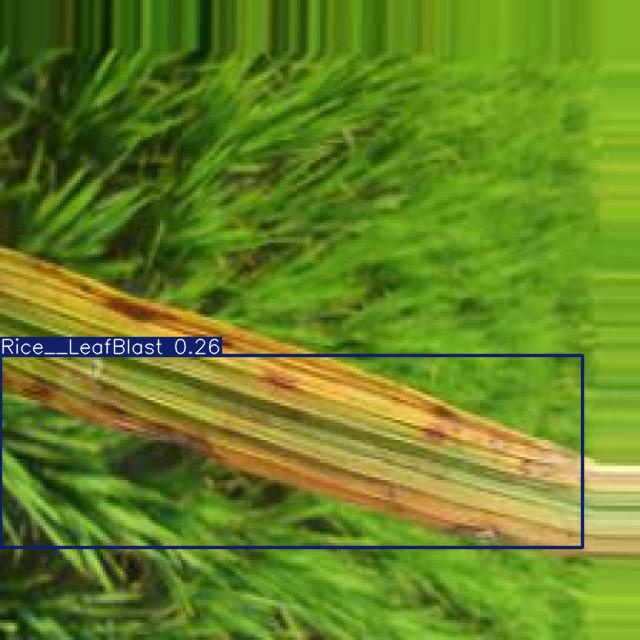

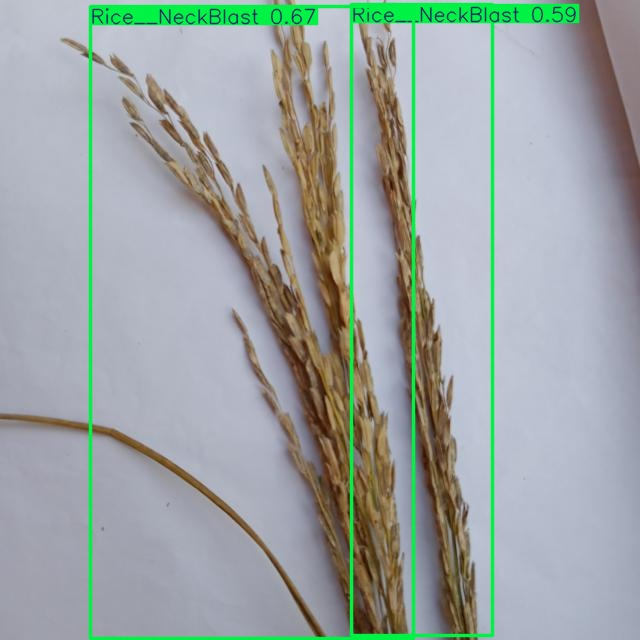

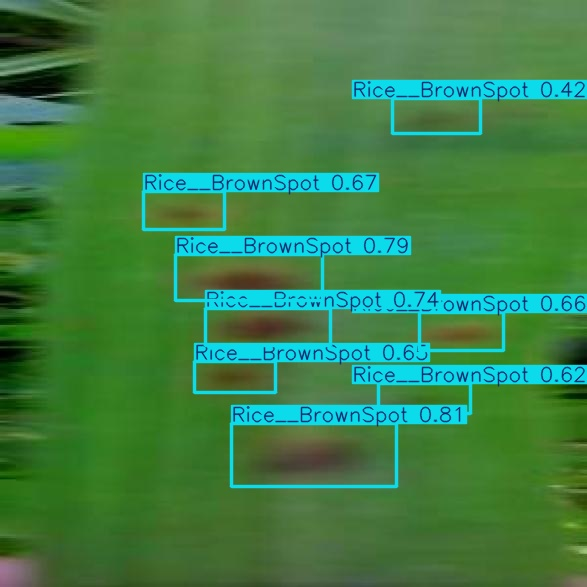

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob
import os
import random

# ✅ PATH BENAR
best_model = YOLO("/content/runs/detect/padisense_runs/yolov8n_baseline/weights/best.pt")

# Ambil 5 gambar random dari validasi
val_images = glob.glob(f'{DATASET_ROOT}/images/val/*.jpg')
test_samples = random.sample(val_images, min(5, len(val_images)))

print(f'Testing {len(test_samples)} gambar...')

for img_path in test_samples:
    results = best_model.predict(
        source=img_path,
        conf=0.25,
        iou=0.45,
        save=True,
        project='/content/padisense_inference',  # biar jelas lokasi
        name='test',
        exist_ok=True,
        verbose=False
    )

    for r in results:
        print(f'\nGambar: {os.path.basename(img_path)}')
        print(f'Deteksi: {len(r.boxes)} objek')

        if r.boxes:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                print(f'  → {CLASS_NAMES[cls_id]} ({conf*100:.1f}%)')
        else:
            print('  → Tidak ada penyakit terdeteksi')

# Tampilkan hasil
result_imgs = glob.glob('/content/padisense_inference/test/*.jpg')
for img in result_imgs[:3]:
    display(Image(img, width=600))

## STEP 10 — Simpan best.pt ke Google Drive

In [ ]:
import shutil

# Folder tujuan di Drive
SAVE_DIR = "/content/drive/MyDrive/PadiSense/model_output"
os.makedirs(SAVE_DIR, exist_ok=True)

# Copy best.pt
src = 'padisense_runs/yolov8n_baseline/weights/best.pt'
dst = f'{SAVE_DIR}/best.pt'
shutil.copy(src, dst)

# Copy last.pt (opsional)
src_last = 'padisense_runs/yolov8n_baseline/weights/last.pt'
shutil.copy(src_last, f'{SAVE_DIR}/last.pt')

# Copy data.yaml
shutil.copy(yaml_path, f'{SAVE_DIR}/data.yaml')

# Copy hasil evaluasi
for fname in ['results.png', 'confusion_matrix.png', 'PR_curve.png']:
    src_f = f'padisense_runs/yolov8n_baseline/{fname}'
    if os.path.exists(src_f):
        shutil.copy(src_f, f'{SAVE_DIR}/{fname}')

print('✅ Semua file berhasil disimpan ke Drive:')
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1e6
    print(f'  {f}  ({size:.1f} MB)')

## BONUS — Eksperimen Lanjutan (Opsional)

Kalau mAP masih kurang, coba salah satu dari ini:

In [ ]:
# ============================================================
# EKSPERIMEN 2: Tambah epoch jadi 100
# Jalankan hanya jika mAP eksperimen 1 < 0.75
# ============================================================

# model2 = YOLO('yolov8n.pt')
# results2 = model2.train(
#     data=yaml_path,
#     epochs=100,
#     imgsz=640,
#     batch=16,
#     patience=20,
#     optimizer='AdamW',
#     project='padisense_runs',
#     name='yolov8n_epoch100',
#     exist_ok=True,
#     device=0
# )

# ============================================================
# EKSPERIMEN 3: Upgrade ke yolov8s jika butuh akurasi lebih
# Lebih berat, estimasi +50% waktu training
# ============================================================

# model3 = YOLO('yolov8s.pt')
# results3 = model3.train(
#     data=yaml_path,
#     epochs=50,
#     imgsz=640,
#     batch=8,           # kurangi batch karena model lebih besar
#     patience=15,
#     optimizer='AdamW',
#     project='padisense_runs',
#     name='yolov8s_baseline',
#     exist_ok=True,
#     device=0
# )

print('Uncomment salah satu eksperimen di atas untuk menjalankannya.')

---
## 📦 Output Format untuk Integrasi Streamlit

Setelah training selesai, file yang dibutuhkan tim frontend:

```
model_output/
├── best.pt        ← model utama
└── data.yaml      ← nama kelas
```

Contoh cara pakai di Streamlit:

```python
from ultralytics import YOLO
from PIL import Image

model = YOLO('best.pt')

def predict(image_path):
    results = model.predict(image_path, conf=0.25)
    output = []
    for r in results:
        for box in r.boxes:
            output.append({
                'disease': model.names[int(box.cls[0])],
                'confidence': round(float(box.conf[0]) * 100, 1),
                'bbox': box.xyxy[0].tolist()
            })
    return output
```

---
**Catatan kelas:**
| ID | Nama Kelas |
|----|------------|
| 0  | Rice__BacterialLeafBlight |
| 1  | Rice__BrownSpot |
| 2  | Rice__Healthy |
| 3  | Rice__Hispa |
| 4  | Rice__LeafBlast |
| 5  | Rice__LeafScald |
| 6  | Rice__LeafSmut |
| 7  | Rice__NarrowBrownLeafSpot |
| 8  | Rice__NeckBlast |